# 🏗️ Taller Semana 7.4 — Escenas Paramétricas 3D

**Objetivo:** Generar objetos 3D de manera programada a partir de listas de coordenadas o datos estructurados.  
Entender cómo crear geometría en tiempo real usando bucles, condicionales y exportar/renderizar escenas.

**Herramientas:** `vedo` · `trimesh` · `open3d` · `numpy`

---
| Sección | Contenido |
|---|---|
| 1 | Instalación y configuración |
| 2 | Lista de coordenadas 3D |
| 3 | Generación paramétrica con `vedo` |
| 4 | Generación paramétrica con `trimesh` |
| 5 | Generación paramétrica con `open3d` |
| 6 | Exportación: OBJ · STL · GLTF |
| 7 | **Bonus** — Leer CSV / JSON y automatizar |


## 1 · Instalación y configuración

In [1]:
# Instalar librerías (ejecutar solo una vez por sesión de Colab)
!pip install vedo trimesh open3d numpy --quiet

# Verificar instalaciones
import vedo, trimesh, open3d, numpy
print(f"vedo   : {vedo.__version__}")
print(f"trimesh: {trimesh.__version__}")
print(f"open3d : {open3d.__version__}")
print(f"numpy  : {numpy.__version__}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 41.9 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 1.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 91.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 6.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 41.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.8 MB/s eta 0:00:00:00:01
vedo   : 2026.6.1
trimesh: 4.12.1
open3d : 0.19.0
numpy  : 2.0.2


In [2]:
import numpy as np
import trimesh
import open3d as o3d
import vedo
from vedo import Plotter, Sphere, Box, Cylinder, Text2D, show
import os, json, csv

# Directorio de salida
OUTPUT_DIR = "outputs_3d"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Directorio de exportación: {OUTPUT_DIR}/")

Directorio de exportación: outputs_3d/


## 2 · Lista de coordenadas 3D

Definimos un conjunto de puntos en el espacio que usaremos como **centros** de las primitivas.  
Cada punto lleva metadatos: `tipo`, `escala` y `color`.

In [3]:
# ─────────────────────────────────────────────────────────────
# Lista de puntos estructurados
#   x, y, z   : posición en el espacio
#   tipo      : 'cubo' | 'esfera' | 'cilindro'
#   escala    : factor de tamaño (float)
#   color     : nombre CSS o hex
# ─────────────────────────────────────────────────────────────
puntos = [
    {"x": 0.0, "y": 0.0, "z": 0.0, "tipo": "cubo",     "escala": 1.0, "color": "#E63946"},
    {"x": 2.5, "y": 0.0, "z": 0.0, "tipo": "esfera",   "escala": 0.8, "color": "#457B9D"},
    {"x": 5.0, "y": 0.0, "z": 0.0, "tipo": "cilindro",  "escala": 1.2, "color": "#2A9D8F"},
    {"x": 0.0, "y": 2.5, "z": 0.0, "tipo": "esfera",   "escala": 1.5, "color": "#E9C46A"},
    {"x": 2.5, "y": 2.5, "z": 0.0, "tipo": "cubo",     "escala": 0.6, "color": "#F4A261"},
    {"x": 5.0, "y": 2.5, "z": 0.0, "tipo": "cilindro",  "escala": 0.9, "color": "#264653"},
    {"x": 1.25,"y": 1.25,"z": 2.0, "tipo": "esfera",   "escala": 2.0, "color": "#A8DADC"},
    {"x": 3.75,"y": 1.25,"z": 2.0, "tipo": "cubo",     "escala": 1.8, "color": "#6D6875"},
    {"x": 2.5, "y": 3.5, "z": 3.0, "tipo": "cilindro",  "escala": 1.0, "color": "#B5838D"},
]

print(f"Total de puntos: {len(puntos)}")
for i, p in enumerate(puntos):
    print(f"  [{i:02d}] ({p['x']:4.1f}, {p['y']:4.1f}, {p['z']:4.1f})  "
          f"tipo={p['tipo']:9s}  escala={p['escala']}  color={p['color']}")

Total de puntos: 9
  [00] ( 0.0,  0.0,  0.0)  tipo=cubo       escala=1.0  color=#E63946
  [01] ( 2.5,  0.0,  0.0)  tipo=esfera     escala=0.8  color=#457B9D
  [02] ( 5.0,  0.0,  0.0)  tipo=cilindro   escala=1.2  color=#2A9D8F
  [03] ( 0.0,  2.5,  0.0)  tipo=esfera     escala=1.5  color=#E9C46A
  [04] ( 2.5,  2.5,  0.0)  tipo=cubo       escala=0.6  color=#F4A261
  [05] ( 5.0,  2.5,  0.0)  tipo=cilindro   escala=0.9  color=#264653
  [06] ( 1.2,  1.2,  2.0)  tipo=esfera     escala=2.0  color=#A8DADC
  [07] ( 3.8,  1.2,  2.0)  tipo=cubo       escala=1.8  color=#6D6875
  [08] ( 2.5,  3.5,  3.0)  tipo=cilindro   escala=1.0  color=#B5838D


## 3 · Generación paramétrica con `vedo`

> `vedo` permite crear primitivas, asignarles color/transparencia y renderizar en Colab con `interactive=False`.

Objetos vedo generados: 9


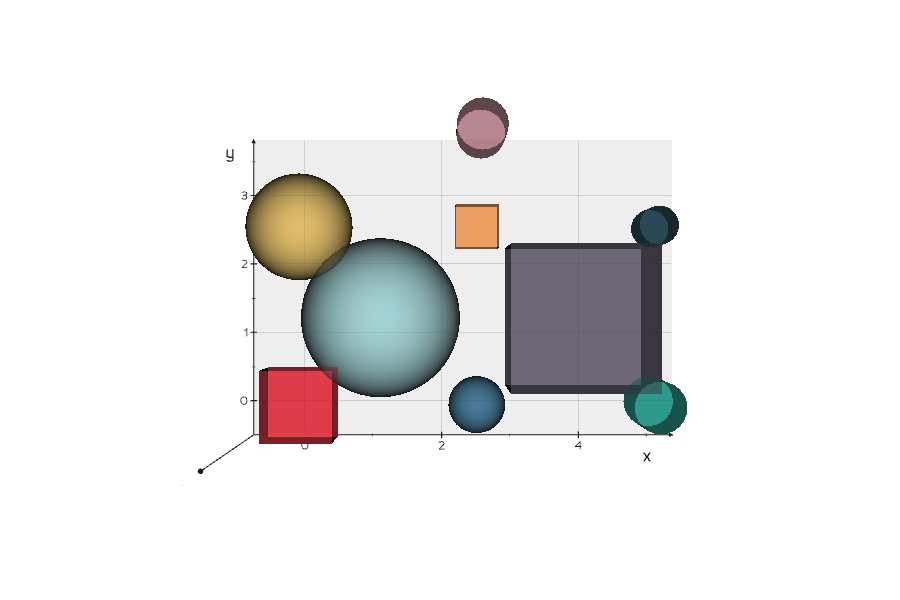

In [4]:
from vedo import Plotter, Sphere, Box, Cylinder

objetos_vedo = []  # acumulamos meshes para exportar después

for p in puntos:
    pos   = [p["x"], p["y"], p["z"]]
    s     = p["escala"]
    color = p["color"]

    if p["tipo"] == "cubo":
        obj = Box(pos=pos, length=s, width=s, height=s)

    elif p["tipo"] == "esfera":
        obj = Sphere(pos=pos, r=s * 0.5)

    elif p["tipo"] == "cilindro":
        # cilindro centrado en pos, radio proporcional a escala
        obj = Cylinder(pos=pos, r=s * 0.3, height=s)

    # Aplicar color y ligera transparencia
    obj.color(color).alpha(0.85)
    objetos_vedo.append(obj)

print(f"Objetos vedo generados: {len(objetos_vedo)}")

# ── Renderizar en Colab ──────────────────────────────────────
plt = Plotter(offscreen=True, size=(900, 600))
plt.show(*objetos_vedo, title="Escena Paramétrica — vedo",
         axes=1, interactive=False, zoom=1.2)
plt.screenshot(f"{OUTPUT_DIR}/escena_vedo.png")
plt.close()

from IPython.display import Image as IPImage
IPImage(f"{OUTPUT_DIR}/escena_vedo.png")

## 4 · Generación paramétrica con `trimesh`

> `trimesh` trabaja directamente con la geometría de malla (vértices + caras).  
> Podemos combinar múltiples primitivas en una sola escena con `trimesh.Scene`.

In [5]:
import trimesh
from trimesh.transformations import translation_matrix

escena_trimesh = trimesh.Scene()

def hex_to_rgba(hex_color: str, alpha: int = 200) -> list:
    """Convierte '#RRGGBB' → [R, G, B, A] en 0-255."""
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return [r, g, b, alpha]

for i, p in enumerate(puntos):
    s     = p["escala"]
    color = hex_to_rgba(p["color"])
    T     = translation_matrix([p["x"], p["y"], p["z"]])

    if p["tipo"] == "cubo":
        mesh = trimesh.creation.box(extents=[s, s, s])

    elif p["tipo"] == "esfera":
        mesh = trimesh.creation.icosphere(subdivisions=3, radius=s * 0.5)

    elif p["tipo"] == "cilindro":
        mesh = trimesh.creation.cylinder(radius=s * 0.3, height=s, sections=32)

    # Asignar color uniforme a toda la malla
    mesh.visual.face_colors = color
    escena_trimesh.add_geometry(mesh, transform=T, node_name=f"{p['tipo']}_{i:02d}")

print(f"Geometrías en la escena trimesh: {len(list(escena_trimesh.geometry))}")
print(f"Bounds de la escena: {escena_trimesh.bounds}")

Geometrías en la escena trimesh: 9
Bounds de la escena: [[-0.75 -0.5  -0.75]
 [ 5.36  3.8   3.5 ]]


## 5 · Generación paramétrica con `open3d`

> `open3d` trabaja con TriangleMesh. Combinaremos todas las mallas en una sola y la visualizaremos.

In [6]:
import open3d as o3d

def hex_to_o3d_color(hex_color: str) -> list:
    """Convierte '#RRGGBB' → [r, g, b] normalizados a [0,1]."""
    h = hex_color.lstrip("#")
    return [int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4)]

meshes_o3d = []

for p in puntos:
    s       = p["escala"]
    color   = hex_to_o3d_color(p["color"])
    traslac = np.array([p["x"], p["y"], p["z"]])

    if p["tipo"] == "cubo":
        mesh = o3d.geometry.TriangleMesh.create_box(width=s, height=s, depth=s)
        # centrar en el punto
        mesh.translate(-np.array([s/2, s/2, s/2]))

    elif p["tipo"] == "esfera":
        mesh = o3d.geometry.TriangleMesh.create_sphere(radius=s * 0.5, resolution=15)

    elif p["tipo"] == "cilindro":
        mesh = o3d.geometry.TriangleMesh.create_cylinder(
            radius=s * 0.3, height=s, resolution=20, split=4
        )

    mesh.translate(traslac)
    mesh.paint_uniform_color(color)
    mesh.compute_vertex_normals()
    meshes_o3d.append(mesh)

# Combinar todas las mallas en una sola
escena_o3d = meshes_o3d[0]
for m in meshes_o3d[1:]:
    escena_o3d += m
escena_o3d.compute_vertex_normals()

print(f"Vértices totales: {len(escena_o3d.vertices)}")
print(f"Triángulos totales: {len(escena_o3d.triangles)}")

Vértices totales: 1596
Triángulos totales: 3156


## 6 · Exportación — OBJ · STL · GLTF

Exportamos la misma escena con las tres herramientas en los tres formatos principales.

In [7]:
# ── 6.1 Exportar con vedo ────────────────────────────────────
# vedo.merge() une todos los objetos en una sola malla
from vedo import merge

merged_vedo = merge(*objetos_vedo)

path_obj_vedo = f"{OUTPUT_DIR}/escena_vedo.obj"
path_stl_vedo = f"{OUTPUT_DIR}/escena_vedo.stl"

vedo.write(merged_vedo, path_obj_vedo)
vedo.write(merged_vedo, path_stl_vedo)

print("vedo exportó:")
print(f"  OBJ → {path_obj_vedo} ({os.path.getsize(path_obj_vedo):,} bytes)")
print(f"  STL → {path_stl_vedo} ({os.path.getsize(path_stl_vedo):,} bytes)")

vedo exportó:
  OBJ → outputs_3d/escena_vedo.obj (221,510 bytes)
  STL → outputs_3d/escena_vedo.stl (332,484 bytes)


In [8]:
# ── 6.2 Exportar con trimesh ──────────────────────────
import os

# Define the paths
path_gltf_trimesh = f"{OUTPUT_DIR}/escena_trimesh.gltf"
path_obj_trimesh = f"{OUTPUT_DIR}/escena_trimesh.obj"
path_stl_trimesh = f"{OUTPUT_DIR}/escena_trimesh.stl"

# 1. Export the whole scene as GLTF
# By passing the file path directly, trimesh handles the "dict vs bytes" logic for you
escena_trimesh.export(path_gltf_trimesh)

# 2. Consolidate into a single mesh
malla_unica = trimesh.util.concatenate(list(escena_trimesh.geometry.values()))

# 3. Export the consolidated mesh as OBJ and STL
# Again, passing the path directly is safer than using export_mesh()
malla_unica.export(path_obj_trimesh)
malla_unica.export(path_stl_trimesh)

# ── Verification ─────────────────────────────────────────────
print("trimesh exportó con éxito:")
print(f"  GLTF → {path_gltf_trimesh} ({os.path.getsize(path_gltf_trimesh):,} bytes)")
print(f"  OBJ  → {path_obj_trimesh} ({os.path.getsize(path_obj_trimesh):,} bytes)")
print(f"  STL  → {path_stl_trimesh} ({os.path.getsize(path_stl_trimesh):,} bytes)")

trimesh exportó con éxito:
  GLTF → outputs_3d/escena_trimesh.gltf (7,593 bytes)
  OBJ  → outputs_3d/escena_trimesh.obj (215,030 bytes)
  STL  → outputs_3d/escena_trimesh.stl (213,084 bytes)


In [9]:
# ── 6.3 Exportar con open3d ──────────────────────────────────
path_obj_o3d = f"{OUTPUT_DIR}/escena_open3d.obj"
path_stl_o3d = f"{OUTPUT_DIR}/escena_open3d.stl"
path_ply_o3d = f"{OUTPUT_DIR}/escena_open3d.ply"  # open3d no exporta GLTF directamente

o3d.io.write_triangle_mesh(path_obj_o3d, escena_o3d)
o3d.io.write_triangle_mesh(path_stl_o3d, escena_o3d)
o3d.io.write_triangle_mesh(path_ply_o3d, escena_o3d)

print("open3d exportó:")
print(f"  OBJ → {path_obj_o3d} ({os.path.getsize(path_obj_o3d):,} bytes)")
print(f"  STL → {path_stl_o3d} ({os.path.getsize(path_stl_o3d):,} bytes)")
print(f"  PLY → {path_ply_o3d} ({os.path.getsize(path_ply_o3d):,} bytes)")

[Open3D WARNING] Write OBJ can not include triangle normals.
open3d exportó:
  OBJ → outputs_3d/escena_open3d.obj (229,862 bytes)
  STL → outputs_3d/escena_open3d.stl (157,884 bytes)
  PLY → outputs_3d/escena_open3d.ply (122,746 bytes)


In [10]:
# ── Resumen de archivos generados ────────────────────────────
print("\n📦 Archivos en outputs_3d/")
print("-" * 50)
for archivo in sorted(os.listdir(OUTPUT_DIR)):
    ruta = os.path.join(OUTPUT_DIR, archivo)
    kb = os.path.getsize(ruta) / 1024
    print(f"  {archivo:<35} {kb:6.1f} KB")


📦 Archivos en outputs_3d/
--------------------------------------------------
  escena_open3d.obj                    224.5 KB
  escena_open3d.ply                    119.9 KB
  escena_open3d.stl                    154.2 KB
  escena_trimesh.gltf                    7.4 KB
  escena_trimesh.obj                   210.0 KB
  escena_trimesh.stl                   208.1 KB
  escena_vedo.obj                      216.3 KB
  escena_vedo.png                       38.2 KB
  escena_vedo.stl                      324.7 KB
  gltf_buffer_0.bin                      0.1 KB
  gltf_buffer_1.bin                      0.1 KB
  gltf_buffer_10.bin                     2.5 KB
  gltf_buffer_11.bin                     0.1 KB
  gltf_buffer_12.bin                     0.0 KB
  gltf_buffer_13.bin                     0.8 KB
  gltf_buffer_14.bin                     0.3 KB
  gltf_buffer_15.bin                     7.5 KB
  gltf_buffer_16.bin                     2.5 KB
  gltf_buffer_17.bin                     0.1 KB
  gltf_buf

## 7 · Bonus — Leer datos desde CSV / JSON y automatizar

Generamos primero los archivos de datos, luego los leemos y regeneramos la escena automáticamente.

In [11]:
# ── 7.1 Crear archivos de datos de ejemplo ───────────────────
import csv, json

# ── CSV ──────────────────────────────────────────────────────
csv_path = f"{OUTPUT_DIR}/puntos_escena.csv"
campos = ["x", "y", "z", "tipo", "escala", "color"]
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=campos)
    writer.writeheader()
    writer.writerows(puntos)

# ── JSON ─────────────────────────────────────────────────────
json_path = f"{OUTPUT_DIR}/puntos_escena.json"
with open(json_path, "w") as f:
    json.dump(puntos, f, indent=2)

print(f"CSV  creado: {csv_path}")
print(f"JSON creado: {json_path}")

CSV  creado: outputs_3d/puntos_escena.csv
JSON creado: outputs_3d/puntos_escena.json


In [12]:
# ── 7.2 Leer desde CSV y generar escena automáticamente ──────
import csv

def cargar_puntos_csv(ruta: str) -> list:
    puntos_csv = []
    with open(ruta, newline="") as f:
        reader = csv.DictReader(f)
        for fila in reader:
            puntos_csv.append({
                "x"     : float(fila["x"]),
                "y"     : float(fila["y"]),
                "z"     : float(fila["z"]),
                "tipo"  : fila["tipo"],
                "escala": float(fila["escala"]),
                "color" : fila["color"],
            })
    return puntos_csv

puntos_desde_csv = cargar_puntos_csv(csv_path)
print(f"Puntos cargados desde CSV: {len(puntos_desde_csv)}")
print(puntos_desde_csv[:3])

Puntos cargados desde CSV: 9
[{'x': 0.0, 'y': 0.0, 'z': 0.0, 'tipo': 'cubo', 'escala': 1.0, 'color': '#E63946'}, {'x': 2.5, 'y': 0.0, 'z': 0.0, 'tipo': 'esfera', 'escala': 0.8, 'color': '#457B9D'}, {'x': 5.0, 'y': 0.0, 'z': 0.0, 'tipo': 'cilindro', 'escala': 1.2, 'color': '#2A9D8F'}]


In [13]:
# ── 7.3 Leer desde JSON y generar escena automáticamente ─────
import json

def cargar_puntos_json(ruta: str) -> list:
    with open(ruta) as f:
        return json.load(f)

puntos_desde_json = cargar_puntos_json(json_path)
print(f"Puntos cargados desde JSON: {len(puntos_desde_json)}")
print(puntos_desde_json[:3])

Puntos cargados desde JSON: 9
[{'x': 0.0, 'y': 0.0, 'z': 0.0, 'tipo': 'cubo', 'escala': 1.0, 'color': '#E63946'}, {'x': 2.5, 'y': 0.0, 'z': 0.0, 'tipo': 'esfera', 'escala': 0.8, 'color': '#457B9D'}, {'x': 5.0, 'y': 0.0, 'z': 0.0, 'tipo': 'cilindro', 'escala': 1.2, 'color': '#2A9D8F'}]


In [14]:
# ── 7.4 Función genérica: datos → escena trimesh → exportar ── (CORREGIDA)
def datos_a_escena(puntos_lista: list, nombre_salida: str) -> str:
    """
    Recibe una lista de dicts con claves x/y/z/tipo/escala/color,
    genera una escena trimesh y exporta a GLTF.
    Retorna la ruta del archivo generado.
    """
    escena = trimesh.Scene()

    for i, p in enumerate(puntos_lista):
        s   = p["escala"]
        clr = hex_to_rgba(p["color"])
        T   = translation_matrix([p["x"], p["y"], p["z"]])

        if p["tipo"] == "cubo":
            mesh = trimesh.creation.box(extents=[s, s, s])
        elif p["tipo"] == "esfera":
            mesh = trimesh.creation.icosphere(subdivisions=2, radius=s * 0.5)
        elif p["tipo"] == "cilindro":
            mesh = trimesh.creation.cylinder(radius=s * 0.3, height=s, sections=24)
        else:
            continue  # tipo desconocido: saltar

        mesh.visual.face_colors = clr
        escena.add_geometry(mesh, transform=T, node_name=f"{p['tipo']}_{i:02d}")

    # Definimos la ruta de salida
    ruta_out = f"{OUTPUT_DIR}/{nombre_salida}.gltf"

    # ── CAMBIO CLAVE AQUÍ ──
    # En lugar de usar export_scene() y open().write(),
    # dejamos que trimesh lo haga todo automáticamente.
    escena.export(ruta_out)

    print(f"✅ Exportado → {ruta_out} ({os.path.getsize(ruta_out):,} bytes)")
    return ruta_out

# Ahora puedes llamar a las funciones sin errores
datos_a_escena(puntos_desde_csv, "auto_desde_csv")
datos_a_escena(puntos_desde_json, "auto_desde_json")

✅ Exportado → outputs_3d/auto_desde_csv.gltf (7,584 bytes)
✅ Exportado → outputs_3d/auto_desde_json.gltf (7,584 bytes)


'outputs_3d/auto_desde_json.gltf'

In [15]:
# ── 7.5 Variación avanzada: grilla procedural con condicionales
# Genera una grilla NxN donde el tipo y tamaño varían según reglas

import math

N = 6           # tamaño de la grilla
SEPARACION = 2.0
puntos_grilla = []

for row in range(N):
    for col in range(N):
        x = col * SEPARACION
        y = row * SEPARACION
        dist_centro = math.sqrt((col - N/2)**2 + (row - N/2)**2)

        # Condicionales para variar tipo, tamaño y color
        if dist_centro < 1.5:
            tipo   = "esfera"
            escala = 1.8
            color  = "#E63946"
        elif dist_centro < 3.0:
            tipo   = "cilindro"
            escala = 1.0 + dist_centro * 0.2
            color  = "#457B9D"
        else:
            tipo   = "cubo"
            escala = 0.5 + (dist_centro / N)
            color  = "#2A9D8F"

        # Altura proporcional a la distancia al centro
        z = dist_centro * 0.3

        puntos_grilla.append({
            "x": x, "y": y, "z": z,
            "tipo": tipo, "escala": round(escala, 2), "color": color
        })

print(f"Puntos en la grilla procedural: {len(puntos_grilla)}")
datos_a_escena(puntos_grilla, "grilla_procedural")

Puntos en la grilla procedural: 36
✅ Exportado → outputs_3d/grilla_procedural.gltf (13,866 bytes)


'outputs_3d/grilla_procedural.gltf'

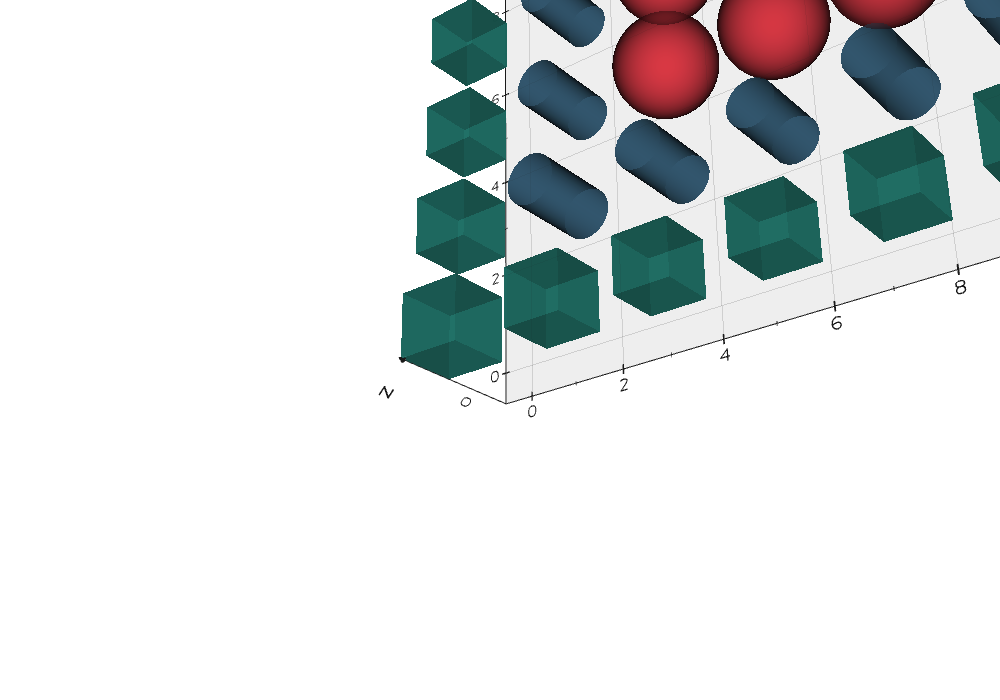

In [16]:
# ── 7.6 Renderizar la grilla procedural con vedo ─────────────
objetos_grilla = []

for p in puntos_grilla:
    pos, s, color = [p["x"], p["y"], p["z"]], p["escala"], p["color"]

    if p["tipo"] == "cubo":
        obj = Box(pos=pos, length=s, width=s, height=s)
    elif p["tipo"] == "esfera":
        obj = Sphere(pos=pos, r=s * 0.5)
    elif p["tipo"] == "cilindro":
        obj = Cylinder(pos=pos, r=s * 0.3, height=s)

    obj.color(color).alpha(0.9)
    objetos_grilla.append(obj)

plt2 = Plotter(offscreen=True, size=(1000, 700))
plt2.show(*objetos_grilla,
          title="Grilla Procedural 6×6 — vedo",
          axes=1, interactive=False, zoom=1.1,
          viewup="z", camera=dict(pos=(15, -10, 18)))
plt2.screenshot(f"{OUTPUT_DIR}/grilla_procedural.png")
plt2.close()

IPImage(f"{OUTPUT_DIR}/grilla_procedural.png")

In [17]:
# ── Resumen final de todos los archivos ──────────────────────
print("\n" + "=" * 55)
print("  ARCHIVOS GENERADOS EN outputs_3d/")
print("=" * 55)

categorias = {
    ".png" : "📸 Renders",
    ".obj" : "📐 OBJ",
    ".stl" : "🖨️  STL",
    ".gltf": "🌐 GLTF",
    ".ply" : "☁️  PLY",
    ".csv" : "📊 Datos CSV",
    ".json": "📋 Datos JSON",
}

for ext, label in categorias.items():
    archivos = [f for f in sorted(os.listdir(OUTPUT_DIR)) if f.endswith(ext)]
    if archivos:
        print(f"\n{label}")
        for a in archivos:
            kb = os.path.getsize(os.path.join(OUTPUT_DIR, a)) / 1024
            print(f"   {a:<40} {kb:6.1f} KB")

total = sum(os.path.getsize(os.path.join(OUTPUT_DIR, f))
            for f in os.listdir(OUTPUT_DIR)) / 1024
print(f"\n{'─'*55}")
print(f"  Total: {len(os.listdir(OUTPUT_DIR))} archivos · {total:.1f} KB")
print("=" * 55)


  ARCHIVOS GENERADOS EN outputs_3d/

📸 Renders
   escena_vedo.png                            38.2 KB
   grilla_procedural.png                      64.2 KB

📐 OBJ
   escena_open3d.obj                         224.5 KB
   escena_trimesh.obj                        210.0 KB
   escena_vedo.obj                           216.3 KB

🖨️  STL
   escena_open3d.stl                         154.2 KB
   escena_trimesh.stl                        208.1 KB
   escena_vedo.stl                           324.7 KB

🌐 GLTF
   auto_desde_csv.gltf                         7.4 KB
   auto_desde_json.gltf                        7.4 KB
   escena_trimesh.gltf                         7.4 KB
   grilla_procedural.gltf                     13.5 KB

☁️  PLY
   escena_open3d.ply                         119.9 KB

📊 Datos CSV
   puntos_escena.csv                           0.3 KB

📋 Datos JSON
   puntos_escena.json                          1.0 KB

───────────────────────────────────────────────────────
  Total: 36 archivos · 16

---

## ✅ Resumen del taller

| Tarea | Herramienta | Estado |
|---|---|---|
| Lista de coordenadas 3D con metadatos | Python puro | ✅ |
| Generación paramétrica (cubo/esfera/cilindro) | `vedo` | ✅ |
| Generación paramétrica + escena | `trimesh` | ✅ |
| Generación paramétrica + combinación | `open3d` | ✅ |
| Exportar OBJ | `vedo.write()` / `trimesh` / `open3d` | ✅ |
| Exportar STL | `vedo.write()` / `trimesh` / `open3d` | ✅ |
| Exportar GLTF | `trimesh.exchange.export` | ✅ |
| **Bonus** — Leer CSV y automatizar | `csv` + `trimesh` | ✅ |
| **Bonus** — Leer JSON y automatizar | `json` + `trimesh` | ✅ |
| **Bonus** — Grilla procedural con condicionales | Python + `vedo` | ✅ |


